# 1. Land Surface Temperature Summer vs Winter

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load data
df = pd.read_csv("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/data/csv/lst_zonal_lc_season_csv.csv")

# Add Temperature difference between Winter and winter
# ensure clean data
df = df.copy()


# reshape so winter and Winter become columns
df_pivot = df.pivot_table(
    index=["gridcode", "lc", "lc_0"],
    columns="season",
    values=["min", "max", "mean", "std", "median"]
)

# flatten column names
df_pivot.columns = ['_'.join(col) for col in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# compute differences (winter - Winter)
df_pivot["min"] = df_pivot["min_Summer"] - df_pivot["min_Winter"]
df_pivot["max"] = df_pivot["max_Summer"] - df_pivot["max_Winter"]
df_pivot["mean"] = df_pivot["mean_Summer"] - df_pivot["mean_Winter"]
df_pivot["std"] = df_pivot["std_Summer"] - df_pivot["std_Winter"]
df_pivot["median"] = df_pivot["median_Summer"] - df_pivot["median_Winter"]

# add season label
df_pivot["season"] = "Summer - Winter"

# final output
df_diff = df_pivot[["season",
    "gridcode", "lc", "lc_0",
    "min", "max", "mean",
    "std", "median"
]]

print(df_diff)


            season  gridcode                   lc                      lc_0  \
0  Summer - Winter         0             1. Water                     Water   
1  Summer - Winter         1       3. Residential               Residential   
2  Summer - Winter         2        4. Industrial  Large low-rise buildings   
3  Summer - Winter         3         6. Wet grass           Irrigated grass   
4  Summer - Winter         4            2. Forest                    Forest   
5  Summer - Winter         5  7. Summer dry grass          Summer dry grass   
6  Summer - Winter         6         5. Bare soil                 Bare soil   
7  Summer - Winter        10  8. Winter dry grass          Winter dry grass   

      min     max    mean    std  median  
0  14.017  21.640  13.802  1.025  13.769  
1  16.457  24.934  23.896  0.429  23.795  
2  20.400  25.064  23.797  0.733  23.998  
3  17.310  26.752  22.430  0.553  22.626  
4  18.179  25.401  22.000  1.082  22.150  
5  21.656  26.374  25.032  0.6

In [6]:
# concat df with df_diff
df = pd.concat([df, df_diff], axis=0, ignore_index=True)

print(df)

             season  gridcode                   lc                      lc_0  \
0            Summer         0             1. Water                     Water   
1            Summer         1       3. Residential               Residential   
2            Summer         2        4. Industrial  Large low-rise buildings   
3            Summer         3         6. Wet grass           Irrigated grass   
4            Summer         4            2. Forest                    Forest   
5            Summer         5  7. Summer dry grass          Summer dry grass   
6            Summer         6         5. Bare soil                 Bare soil   
7            Summer        10  8. Winter dry grass          Winter dry grass   
8            Winter         0             1. Water                     Water   
9            Winter         1       3. Residential               Residential   
10           Winter         2        4. Industrial  Large low-rise buildings   
11           Winter         3         6.

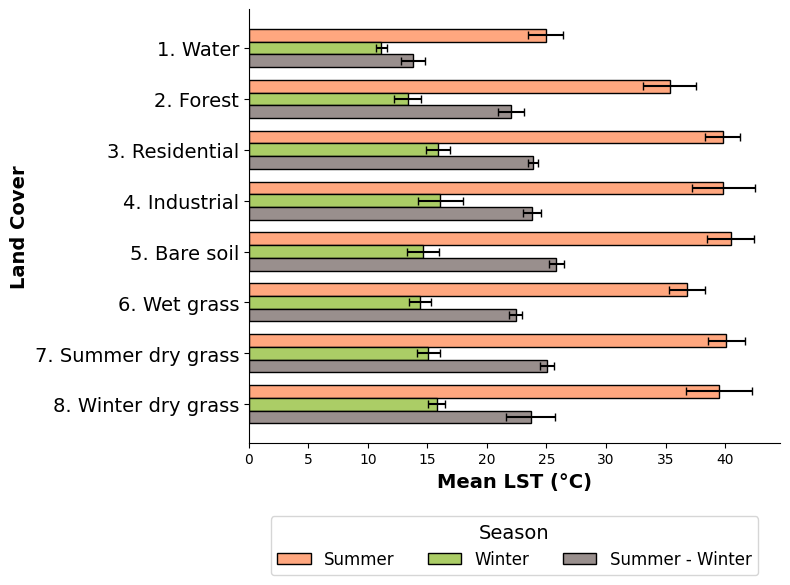

In [7]:
# Colors
lc_colors = {
    "Summer": "#FFA77F",
    "Winter": "#ABCD66",
    "Summer - Winter": "#998F8D"
}

# Categories
lc_categories = sorted(df["lc"].unique())
seasons = ["Summer", "Winter", "Summer - Winter"]

# y positions (because LC is now vertical axis)
y = np.arange(len(lc_categories))
height = 0.25

plt.figure(figsize=(8, 6))

for i, season in enumerate(seasons):
    subset = df[df["season"] == season]

    means = []
    stds = []

    for lc in lc_categories:
        row = subset[subset["lc"] == lc]

        if not row.empty:
            means.append(row["mean"].values[0])
            stds.append(row["std"].values[0])
        else:
            means.append(np.nan)
            stds.append(np.nan)

    plt.barh(
        y + i * height - height,
        means,
        height,
        label=season,
        color=lc_colors[season],
        edgecolor="black"
    )

    plt.errorbar(
        means,
        y + i * height - height,
        xerr=stds,
        fmt="none",
        ecolor="black",
        capsize=3
    )

# Labels
plt.xlabel("Mean LST (°C)", fontsize=14, fontweight="bold")
plt.ylabel("Land Cover", fontsize=14, fontweight="bold")

plt.yticks(y, lc_categories, fontsize=14)
plt.gca().invert_yaxis()


plt.legend(title="Season", fontsize=12, title_fontsize=14)

# Clean style
ax = plt.gca()
ax.set_facecolor("white")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Legend at the bottom
plt.legend(
    title="Season",
    fontsize=12,
    title_fontsize=14,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3
)

plt.tight_layout()

# Save
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/lst_summer_winter_difference_land_cover.png", dpi=300, bbox_inches="tight")

plt.show()

# 2. Turning Points
# Comparison Between Techniques

| Aspect | ΔLST Threshold (`delta_Tt`) | Near-Zero Slope |
|--------|-----------------------------|----------------|
| Concept | Local maxima/minima | Flattening zones |
| Computation | Δ between consecutive points | Gradient (dLST/dx) |
| Threshold Meaning | Minimum ΔLST to detect turning | Maximum slope to detect flattening |
| Output | Peak/trough point | First “flat” point after central LST |
| Use Case | Detect abrupt changes | Detect gradual stabilization |


## 2.1 Based on ΔLST (delta_Tt)
**Objective:** Identify local maxima or minima in the smoothed LST curve.  

**Method:**
1. Fit a cubic smoothing spline to the LST profile along buffer distances.
2. Compute the **difference between consecutive smoothed points**:
   
   \[
   \Delta T = LST_{i+1} - LST_i
   \]

3. Compute threshold:

   \[
   \Delta T_{threshold} = Pert \times (T_{max} - T_{min})
   \]

   where `Pert` is a small proportion (e.g., 0.0005 for high-resolution Landsat data), and \(T_{max}\) / \(T_{min}\) are the maximum and minimum LST in the profile.

4. Loop through `ΔT` and identify the **first sign change** (ΔT[k] * ΔT[k+1] ≤ 0) that is larger than the threshold.  
   This corresponds to a **turning point** (peak or trough).

**Notes:**
- Sensitive to **step size** between buffers.
- Useful to detect **local maxima/minima**.
- Threshold may need adjustment depending on LST resolution (MODIS vs. Landsat).


When detecting **turning points** or **near-zero slope points** in LST gradients, the threshold depends on the spatial resolution of the data. MODIS and Landsat have very different resolutions, so thresholds must be scaled accordingly.

**Scaling LST Turning Point Thresholds from MODIS to 250 m Buffers**

When detecting **turning points** or **near-zero slope points** in LST gradients, the threshold depends on the **spatial resolution** of the data and the step along which we compute the gradient.  

Here, the **unit is a 250 m buffer**, corresponding to typical LCZ classification zones.

---

1️⃣ Original MODIS Threshold

- Literature threshold for MODIS (1 km resolution):  

\[
\Delta T_t^\text{MODIS} = 0.02
\]  

- MODIS resolution: \(R_\text{MODIS} = 1000~\text{m}\)  

This threshold represents the **minimum LST change along one MODIS pixel** to be considered a turning point.

---

2️⃣ Number of Buffers per MODIS Pixel

- Buffer width: \(R_\text{buffer} = 250~\text{m}\)  
- Buffers along one axis in a MODIS pixel:  

\[
N_\text{axis} = \frac{R_\text{MODIS}}{R_\text{buffer}} = \frac{1000}{250} = 4
\]  

- Total number of 250 m buffers inside **one MODIS pixel (2D)**:  

\[
N_\text{pixel} = N_\text{axis}^2 = 4 \times 4 = 16
\]  

---

3️⃣ Scale Threshold to 250 m Buffer

- Threshold per buffer:

\[
\Delta T_t^\text{buffer} = \frac{\Delta T_t^\text{MODIS}}{N_\text{pixel}} = \frac{0.02}{16} = 0.00125
\]  

- Use **0.00125** as the turning point threshold for gradients computed per 250 m buffer.

---

4️⃣ Near-Zero Slope Threshold

- If MODIS near-zero slope threshold is \(\epsilon_\text{MODIS} = 0.01\), the per-buffer threshold:

\[
\epsilon_\text{buffer} = \frac{\epsilon_\text{MODIS}}{16} = 0.000625
\]  

- This gives a **slope per buffer unit** consistent with the original MODIS sensitivity.

---

5️⃣ General Formula

For any new buffer width \(R_\text{buffer}\):

\[
\text{Threshold}_\text{buffer} = \text{Threshold}_\text{original} \times \frac{R_\text{buffer}^2}{R_\text{original}^2}
\]

- MODIS → 250 m buffer:

\[
0.02 \times \frac{250^2}{1000^2} = 0.00125
\]

- Works for **ΔLST turning points** and **near-zero slope points**.

---

6️⃣ Notes

1. Assumes **linear scaling along both axes** (first-order approximation).  
2. After scaling, **visual inspection is recommended** to ensure thresholds detect meaningful turning points and avoid noise.  
3. If LST is noisy at fine scale, consider **slightly increasing the threshold** (e.g., ×1.5) to reduce false positives.

### 2.1.1 Summer

In [120]:
# Import necessary libraries
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(sys.executable)
print(pd.__version__)

c:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\.venv\Scripts\python.exe
1.3.5


In [121]:
# Load the gradient metadata from the CSV file
gradient_metadata = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\data\csv\constructed_buffer_metadata_250.csv")

# View the first 5 rows of the gradient metadata
print(gradient_metadata.head())

   direction  distance  buffer_no  buffer_id          area
0         15       0.0          0          1  18536.558476
1         45       0.0          0          2  15894.732445
2         75       0.0          0          3  12460.969177
3        285       0.0          0          4  12754.232022
4        315       0.0          0          5  10741.624205


In [122]:
# Load the mean SUMMER LST data from the CSV file
summer_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\data\csv\lst_2023_250m.csv")

# View the first 5 rows
print(summer_lst.head())

   buffer_id  lst_mean
0          1   39.2536
1          2   38.8929
2          3   38.2114
3          4   40.4331
4          5   40.0731


In [123]:
# Join the summer_lst DataFrame with the gradient metadata DataFrame on the buffer_id column
summer_lst_gradient = pd.merge(summer_lst, gradient_metadata, on='buffer_id')

# Keep only desired columns
summer_lst_gradient = summer_lst_gradient[["buffer_id", "buffer_no", "distance", "direction", "lst_mean"]]

# View the first 5 rows of the joined DataFrame
print(summer_lst_gradient.head(10))

# save the joined DataFrame to a new CSV file
summer_lst_gradient.to_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\data\csv\summer_lst_gradient_csv.csv", index=False)

   buffer_id  buffer_no  distance  direction  lst_mean
0          1          0      0.00         15   39.2536
1          2          0      0.00         45   38.8929
2          3          0      0.00         75   38.2114
3          4          0      0.00        285   40.4331
4          5          0      0.00        315   40.0731
5          6          0      0.00        345   39.4016
6          7          1      0.25         15   38.3270
7          8          1      0.25         45   37.5681
8          9          1      0.25         75   36.4224
9         10          1      0.25        285   41.2985


In [124]:
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

# --------------------------
# 1. Filter directions
# --------------------------
summer_lst_gradient = summer_lst_gradient[summer_lst_gradient["direction"].isin([285, 315, 345])]

summer_df_spline_list = []
summer_turning_points = []

# --------------------------
# 2. Loop per direction
# --------------------------
for direction, group in summer_lst_gradient.groupby("direction"):
    
    group = group.sort_values("buffer_no")
    
    x = group["buffer_no"].values
    y = group["lst_mean"].values
    
    # --------------------------
    # 3. Cubic smoothing spline
    # --------------------------
    # s controls smoothing strength (tune this!)
    s_value = len(x) * np.var(y) * 0.1   # good starting point
    spline = UnivariateSpline(x, y, k=3, s=s_value)
    
    pred = spline(x)
    
    # Force exact value at distance = 0
    idx0 = np.where(x == 0)[0]
    if len(idx0):
        pred[idx0[0]] = y[idx0[0]]
    
    # Store smoothed curve
    summer_df_spline_list.append(pd.DataFrame({
        "buffer_no": x,
        "lst_mean": pred,
        "direction": direction
    }))
    
print("Rows:", len(summer_lst_gradient))
print("Columns:", summer_lst_gradient.columns)
print("Unique directions:", summer_lst_gradient["direction"].unique())
print(summer_lst_gradient.groupby("direction").size())


Rows: 139
Columns: Index(['buffer_id', 'buffer_no', 'distance', 'direction', 'lst_mean'], dtype='object')
Unique directions: [285 315 345]
direction
285    34
315    63
345    42
dtype: int64


In [160]:
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

summer_df_spline_list = []
summer_turning_points = []

for direction, group in summer_lst_gradient.groupby("direction"):
    
    # Safety: ensure enough points
    if len(group) < 4:
        print(f"Skipping direction {direction} (not enough points)")
        continue
    
    group = group.sort_values("buffer_no")
    
    x = group["buffer_no"].values
    y = group["lst_mean"].values
    
    # --------------------------
    # Cubic smoothing spline
    # --------------------------
    s_value = len(x) * np.var(y) * 0.1
    spline = UnivariateSpline(x, y, k=3, s=s_value)
    
    pred = spline(x)
    
     
    # Store smoothed curve
    summer_df_spline_list.append(pd.DataFrame({
        "buffer_no": x,
        "lst_mean": pred,
        "direction": direction
    }))
    
    # --------------------------
    # Turning point detection
    # --------------------------
    delta_T = np.diff(pred)
    
    Tmax = np.max(pred)
    Tmin = np.min(pred)
    
    delta_Tt = 0.00125 * (Tmax - Tmin)
    
    found = False
    
    for k in range(len(delta_T) - 1):
        
        cond1 = abs(delta_T[k]) > delta_Tt
        cond2 = delta_T[k] * delta_T[k+1] <= 0
        
        if cond1 and cond2:
            summer_turning_points.append({
                "direction": direction,
                "buffer_no": x[k],
                "lst": pred[k]
            })
            found = True
            break
    
    # Optional: track if no turning point found
    if not found:
        print(f"No turning point found for direction {direction}")

# --------------------------
# Combine outputs safely
# --------------------------
if summer_df_spline_list:
    summer_df_spline = pd.concat(summer_df_spline_list, ignore_index=True)
else:
    summer_df_spline = pd.DataFrame()

summer_df_turning = pd.DataFrame(summer_turning_points)

print(summer_df_turning)


   direction  buffer_no        lst
0        285          1  40.850206
1        315          5  38.827963
2        345          7  37.728551


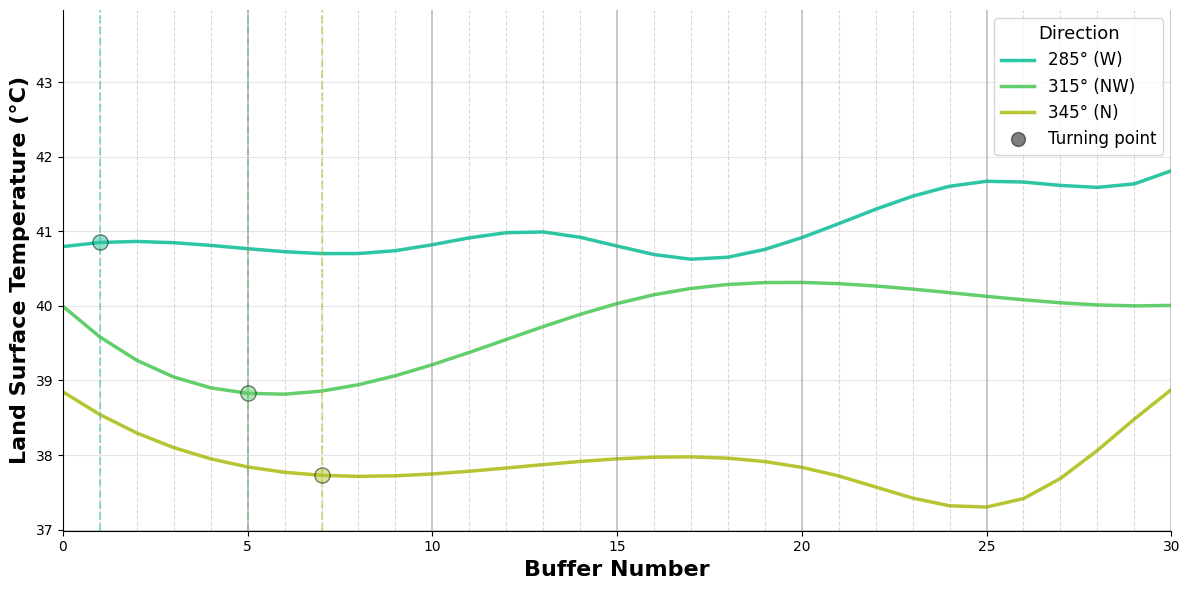

In [161]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --------------------------
# Colors (integer keys)
# --------------------------
colors = {
    285: "#2cc6a4",
    315: "#63cf6c",
    345: "#b7c532"
}

plt.figure(figsize=(12, 6))
ax = plt.gca()

# --------------------------
# 1. Plot smoothed curves
# --------------------------
for direction, group in summer_df_spline.groupby("direction"):
    if direction in colors:
        plt.plot(
            group["buffer_no"],
            group["lst_mean"],
            linewidth=2.5,
            color=colors[direction],
            label=f"{direction}°"
        )

# --------------------------
# 2. Plot turning points (colored by direction, semi-transparent)
# --------------------------
turn_x = summer_df_turning["buffer_no"].tolist()
turn_y = summer_df_turning["lst"].tolist()
turn_dir = summer_df_turning["direction"].tolist()

for x_val, y_val, direction in zip(turn_x, turn_y, turn_dir):
    dir_color = colors.get(direction, "black")
    # Point
    plt.scatter(
        x_val,
        y_val,
        s=120,
        color=dir_color,
        edgecolor="black",
        alpha=0.5,
        zorder=6
    )
    # Vertical dashed line at turning point
    plt.axvline(
        x=x_val,
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        color=dir_color
    )

# --------------------------
# 3. X-axis vertical lines
# --------------------------
x_values = np.arange(0, 31, 1)
solid_lines = [5, 10, 15, 20, 25, 30]

for x in x_values:
    if x in solid_lines:
        ax.axvline(x=x, linestyle='-', color='grey', alpha=0.5, linewidth=1.2)
    else:
        ax.axvline(x=x, linestyle='--', color='grey', alpha=0.3, linewidth=0.8)

# --------------------------
# 4. Gray horizontal line along x-axis
# --------------------------
plt.axhline(y=ax.get_ylim()[0], color='grey', linewidth=1)

# --------------------------
# 5. Labels
# --------------------------
plt.xlabel("Buffer Number", fontsize=16, fontweight="bold")
plt.ylabel("Land Surface Temperature (°C)", fontsize=16, fontweight="bold")
ax.set_xlim(0, 30)
ax.set_xticks(np.arange(0, 31, 5))  # default ticks

# --------------------------
# 6. Grid + background styling
# --------------------------
plt.grid(axis='y', alpha=0.3)
ax.set_facecolor("white")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# --------------------------
# 7. Legend
# --------------------------
legend_elements = [
    Line2D([0], [0], color=colors[285], lw=2.5, label="285° (W)"),
    Line2D([0], [0], color=colors[315], lw=2.5, label="315° (NW)"),
    Line2D([0], [0], color=colors[345], lw=2.5, label="345° (N)"),
    Line2D([0], [0], marker='o', color='w', label='Turning point',
           markerfacecolor='black', markeredgecolor='black', alpha=0.5, markersize=10)
]
plt.legend(handles=legend_elements, title="Direction", fontsize=12, title_fontsize=13)

# --------------------------
# 8. Layout + Save
# --------------------------
plt.tight_layout()
plt.savefig(
    "C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/summer_turning_points_spline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### 2.1.2 Winter

In [131]:

winter_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\data\csv\lst_2022_250m.csv")

# View the first 5 rows
print(winter_lst.head())

   buffer_id  lst_mean
0          1  15.78817
1          2  15.18015
2          3  14.79623
3          4  16.24522
4          5  16.36909


In [132]:
# Join the winter_lst DataFrame with the gradient metadata DataFrame on the buffer_id column
winter_lst_gradient = pd.merge(winter_lst, gradient_metadata, on='buffer_id')

# Keep only desired columns
winter_lst_gradient = winter_lst_gradient[["buffer_id", "buffer_no", "distance", "direction", "lst_mean"]]

# View the first 5 rows of the joined DataFrame
print(winter_lst_gradient.head(10))

# save the joined DataFrame to a new CSV file
winter_lst_gradient.to_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD_chapter2_IGARSS\data\csv\winter_lst_gradient_csv.csv", index=False)

   buffer_id  buffer_no  distance  direction  lst_mean
0          1          0      0.00         15  15.78817
1          2          0      0.00         45  15.18015
2          3          0      0.00         75  14.79623
3          4          0      0.00        285  16.24522
4          5          0      0.00        315  16.36909
5          6          0      0.00        345  15.99051
6          7          1      0.25         15  14.81404
7          8          1      0.25         45  14.11940
8          9          1      0.25         75  13.83684
9         10          1      0.25        285  15.76616


In [133]:
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

# --------------------------
# 1. Filter directions
# --------------------------
winter_lst_gradient = winter_lst_gradient[winter_lst_gradient["direction"].isin([285, 315, 345])]

winter_df_spline_list = []
winter_turning_points = []

# --------------------------
# 2. Loop per direction
# --------------------------
for direction, group in winter_lst_gradient.groupby("direction"):
    
    group = group.sort_values("buffer_no")
    
    x = group["buffer_no"].values
    y = group["lst_mean"].values
    
    # --------------------------
    # 3. Cubic smoothing spline
    # --------------------------
    # s controls smoothing strength (tune this!)
    s_value = len(x) * np.var(y) * 0.1   # good starting point
    spline = UnivariateSpline(x, y, k=3, s=s_value)
    
    pred = spline(x)
    
    # Force exact value at distance = 0
    idx0 = np.where(x == 0)[0]
    if len(idx0):
        pred[idx0[0]] = y[idx0[0]]
    
    # Store smoothed curve
    winter_df_spline_list.append(pd.DataFrame({
        "buffer_no": x,
        "lst_mean": pred,
        "direction": direction
    }))
    
print("Rows:", len(winter_lst_gradient))
print("Columns:", winter_lst_gradient.columns)
print("Unique directions:", winter_lst_gradient["direction"].unique())
print(winter_lst_gradient.groupby("direction").size())


Rows: 139
Columns: Index(['buffer_id', 'buffer_no', 'distance', 'direction', 'lst_mean'], dtype='object')
Unique directions: [285 315 345]
direction
285    34
315    63
345    42
dtype: int64


In [162]:
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline

winter_df_spline_list = []
winter_turning_points = []

for direction, group in winter_lst_gradient.groupby("direction"):
    
    # Safety: ensure enough points
    if len(group) < 4:
        print(f"Skipping direction {direction} (not enough points)")
        continue
    
    group = group.sort_values("buffer_no")
    
    x = group["buffer_no"].values
    y = group["lst_mean"].values
    
    # --------------------------
    # Cubic smoothing spline
    # --------------------------
    s_value = len(x) * np.var(y) * 0.1
    spline = UnivariateSpline(x, y, k=3, s=s_value)
    
    pred = spline(x)
    
     
    # Store smoothed curve
    winter_df_spline_list.append(pd.DataFrame({
        "buffer_no": x,
        "lst_mean": pred,
        "direction": direction
    }))
    
    # --------------------------
    # Turning point detection
    # --------------------------
    delta_T = np.diff(pred)
    
    Tmax = np.max(pred)
    Tmin = np.min(pred)
    
    delta_Tt = 0.00125 * (Tmax - Tmin)
    
    found = False
    
    for k in range(len(delta_T) - 1):
        
        cond1 = abs(delta_T[k]) > delta_Tt
        cond2 = delta_T[k] * delta_T[k+1] <= 0
        
        if cond1 and cond2:
            winter_turning_points.append({
                "direction": direction,
                "buffer_no": x[k],
                "lst": pred[k]
            })
            found = True
            break
    
    # Optional: track if no turning point found
    if not found:
        print(f"No turning point found for direction {direction}")

# --------------------------
# Combine outputs safely
# --------------------------
if winter_df_spline_list:
    winter_df_spline = pd.concat(winter_df_spline_list, ignore_index=True)
else:
    winter_df_spline = pd.DataFrame()

winter_df_turning = pd.DataFrame(winter_turning_points)

print(winter_df_turning)


   direction  buffer_no        lst
0        285          3  15.524015
1        315          9  14.838951
2        345          3  14.538529


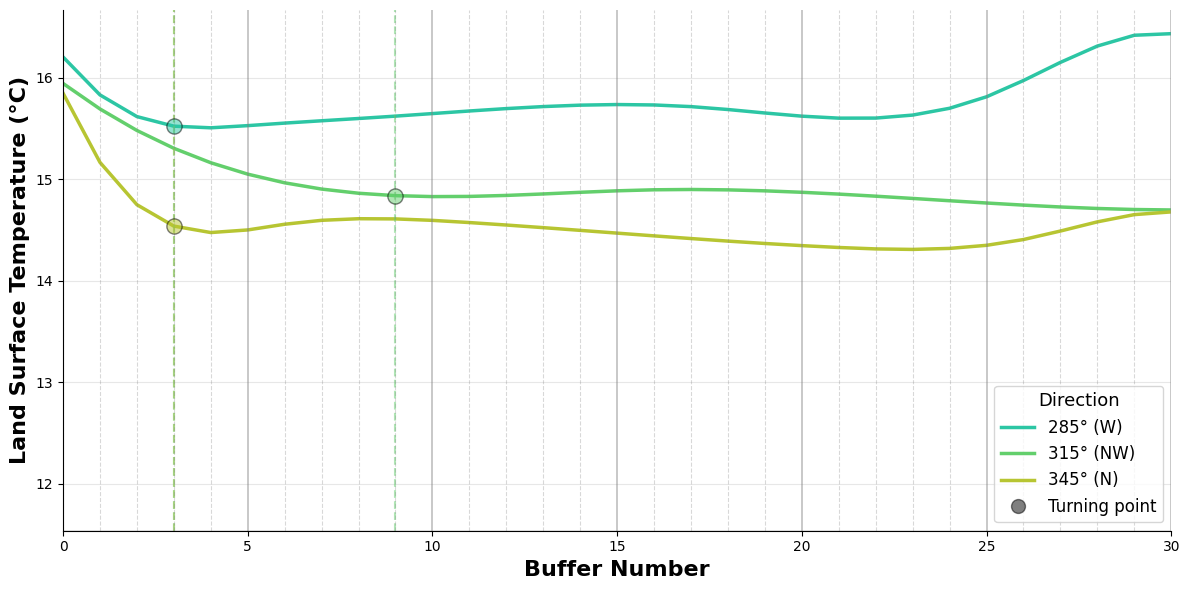

In [163]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --------------------------
# Colors (integer keys)
# --------------------------
colors = {
    285: "#2cc6a4",
    315: "#63cf6c",
    345: "#b7c532"
}

plt.figure(figsize=(12, 6))
ax = plt.gca()

# --------------------------
# 1. Plot smoothed curves
# --------------------------
for direction, group in winter_df_spline.groupby("direction"):
    if direction in colors:
        plt.plot(
            group["buffer_no"],
            group["lst_mean"],
            linewidth=2.5,
            color=colors[direction],
            label=f"{direction}°"
        )

# --------------------------
# 2. Plot turning points (colored by direction, semi-transparent)
# --------------------------
turn_x = winter_df_turning["buffer_no"].tolist()
turn_y = winter_df_turning["lst"].tolist()
turn_dir = winter_df_turning["direction"].tolist()

for x_val, y_val, direction in zip(turn_x, turn_y, turn_dir):
    dir_color = colors.get(direction, "black")
    # Point
    plt.scatter(
        x_val,
        y_val,
        s=120,
        color=dir_color,
        edgecolor="black",
        alpha=0.5,
        zorder=6
    )
    # Vertical dashed line at turning point
    plt.axvline(
        x=x_val,
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        color=dir_color
    )

# --------------------------
# 3. X-axis vertical lines
# --------------------------
x_values = np.arange(0, 31, 1)
solid_lines = [5, 10, 15, 20, 25, 30]

for x in x_values:
    if x in solid_lines:
        ax.axvline(x=x, linestyle='-', color='grey', alpha=0.5, linewidth=1.2)
    else:
        ax.axvline(x=x, linestyle='--', color='grey', alpha=0.3, linewidth=0.8)

# --------------------------
# 4. Gray horizontal line along x-axis
# --------------------------
plt.axhline(y=ax.get_ylim()[0], color='grey', linewidth=1)

# --------------------------
# 5. Labels
# --------------------------
plt.xlabel("Buffer Number", fontsize=16, fontweight="bold")
plt.ylabel("Land Surface Temperature (°C)", fontsize=16, fontweight="bold")
ax.set_xlim(0, 30)
ax.set_xticks(np.arange(0, 31, 5))  # default ticks

# --------------------------
# 6. Grid + background styling
# --------------------------
plt.grid(axis='y', alpha=0.3)
ax.set_facecolor("white")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# --------------------------
# 7. Legend
# --------------------------
legend_elements = [
    Line2D([0], [0], color=colors[285], lw=2.5, label="285° (W)"),
    Line2D([0], [0], color=colors[315], lw=2.5, label="315° (NW)"),
    Line2D([0], [0], color=colors[345], lw=2.5, label="345° (N)"),
    Line2D([0], [0], marker='o', color='w', label='Turning point',
           markerfacecolor='black', markeredgecolor='black', alpha=0.5, markersize=10)
]
plt.legend(handles=legend_elements, title="Direction", fontsize=12, title_fontsize=13)

# --------------------------
# 8. Layout + Save
# --------------------------
plt.tight_layout()
plt.savefig(
    "C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/winter_turning_points_spline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 2.2 Near-zero slope

The near-zero slope turning point represents the buffer distance at which the LST curve becomes nearly flat, meaning that further increases in distance no longer produce meaningful changes in temperature. In other words, it marks the point where the cooling effect of the surrounding landscape stabilizes and reaches a saturation level.

Mathematically, this condition is defined as:

$$
\frac{dT(x)}{dx} \approx 0 \quad \text{for } x = x^*
$$

In discrete form, it is identified as:

$$
x^* = \min \{ x_i \;|\; |\nabla LST(x_i)| < \epsilon \}
$$

Where:
* **$\text{LST}(x_i)$** is the LST at distance $x_i$.
* **$\nabla LST(x_i)$** is the numerical slope.
* **$\epsilon$** is a small threshold defining “near-zero” change.

# Detecting Flattening Zones Using Near-Zero Slope

**Objective:** Identify points along the LST curve where the gradient becomes nearly zero, i.e., the curve flattens.  

**Method:**
1. Compute the slope of the smoothed LST curve with respect to buffer distance:

   \[
   \frac{dLST}{dx} \approx \text{np.gradient}(LST, buffer\_distance)
   \]

2. Define a **near-zero slope threshold** (`threshold`).  
   - Absolute value of slope below this threshold is considered “flat”.  
   - Can be fixed (e.g., `0.01 °C per buffer unit`) or adaptive:

   \[
   threshold = 0.005 \times (LST_{max} - LST_{min})
   \]

3. Select the **first buffer distance** where the slope is below the threshold.

**Notes:**
- Sensitive to the magnitude of LST variation; adaptive threshold ensures scaling across datasets.
- Finds **flattening zones**, not necessarily the exact peak or trough.
- Useful for detecting the point where LST stabilizes after decreasing from urban core.




### 2.2.1 Summer

In [152]:
summer_turning_points_near_zero = []

for direction, group in summer_df_spline.groupby("direction"):

    group = group.sort_values("buffer_no")

    x_vals = group["buffer_no"].values
    y_vals = group["lst_mean"].values

    dydx = np.gradient(y_vals, x_vals)

    idx0 = np.where(x_vals == 0)[0]
    y0 = y_vals[idx0[0]] if len(idx0) > 0 else y_vals[0]

    mask = y_vals < y0

    x_masked = x_vals[mask]
    y_masked = y_vals[mask]
    slope_masked = dydx[mask]

    threshold = 0.004

    near_zero_idx = np.where(np.abs(slope_masked) < threshold)[0]

    if len(near_zero_idx) > 0:

        idx = near_zero_idx[0]

        summer_turning_points_near_zero.append({
            "direction": direction,
            "buffer_no": x_masked[idx],
            "lst": y_masked[idx],
            "method": "near_zero_slope"
        })


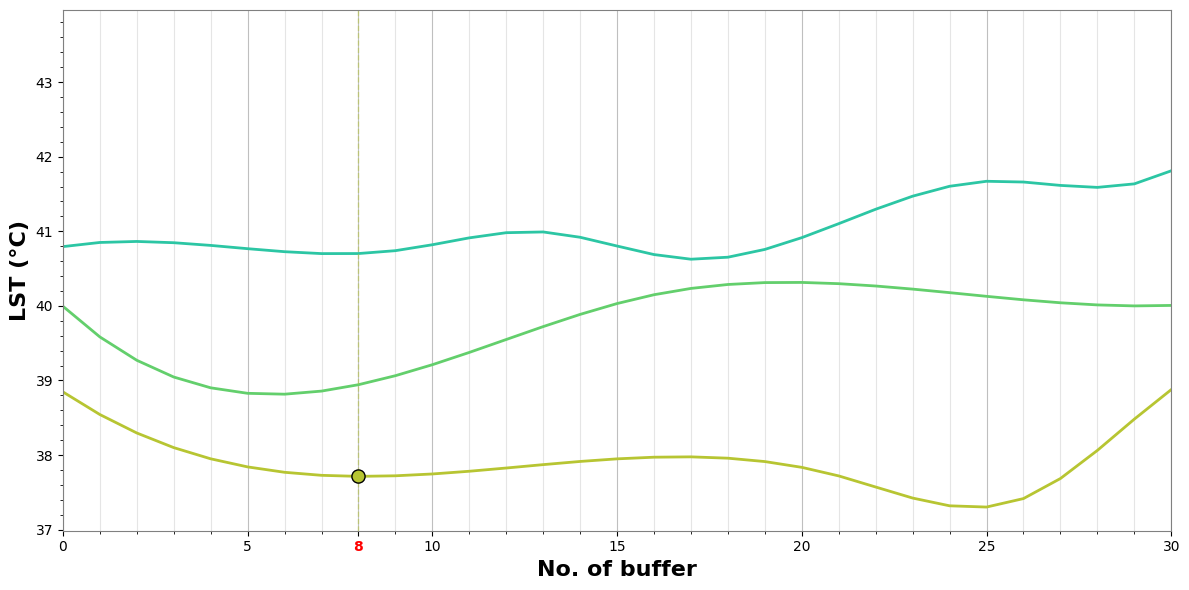

In [153]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_tp = pd.DataFrame(summer_turning_points_near_zero)

# --------------------------
# 0. Create figure FIRST
# --------------------------
plt.figure(figsize=(12, 6))
ax = plt.gca()

# --------------------------
# 1. Plot curves
# --------------------------
for direction, group in summer_df_spline.groupby("direction"):

    group = group.sort_values("buffer_no")

    plt.plot(
        group["buffer_no"],
        group["lst_mean"],
        linewidth=2,
        color=colors.get(direction, "black"),
        label=f"Direction {direction}"
    )

# --------------------------
# 2. Plot near-zero slope points
# --------------------------
for _, row in df_tp.iterrows():

    plt.scatter(
        row["buffer_no"],
        row["lst"],
        s=90,
        color=colors.get(row["direction"], "black"),
        edgecolor="black",
        zorder=5
    )

    # vertical line (optional but useful)
    plt.axvline(
        x=row["buffer_no"],
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        color=colors.get(row["direction"], "black")
    )

# --------------------------
# 3. Labels
# --------------------------
plt.xlabel("No. of buffer", fontsize=16, fontweight="bold")
plt.ylabel("LST (°C)", fontsize=16, fontweight="bold")


# --------------------------
# 4. X-axis ticks
# --------------------------
plt.xticks(np.arange(0, 31, 5))

ax = plt.gca()

# --------------------------
# Base ticks
# --------------------------
base_ticks = list(np.arange(0, 31, 5))

# --------------------------
# Turning points (near-zero slope)
# --------------------------
turn_ticks = df_tp["buffer_no"].astype(int).tolist()

# --------------------------
# Merge + clean
# --------------------------
all_ticks = sorted(set(base_ticks + turn_ticks))

ax.set_xticks(all_ticks)
ax.set_xticklabels([str(t) for t in all_ticks])

# --------------------------
# Highlight turning points
# --------------------------
for label, tick in zip(ax.get_xticklabels(), all_ticks):
    if tick in turn_ticks:
        label.set_fontweight("bold")
        label.set_color("red")   # you can replace with colors dict later


# --------------------------
# 5. Grid styling
# --------------------------
plt.grid(axis="x", which="major", color="grey", alpha=0.5)
plt.minorticks_on()
plt.grid(axis="x", which="minor", color="grey", alpha=0.2)

ax.set_xlim(0, 30)

# --------------------------
# 6. Clean spines
# --------------------------
for spine in ax.spines.values():
    spine.set_edgecolor("grey")

ax.set_facecolor("white")

# --------------------------
# 7. Legend (bottom)
# --------------------------
#plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4)

plt.tight_layout()

# Save
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/summer_turning_points_near_zero_slope.png", dpi=300, bbox_inches="tight")

plt.show()


### 2.2.2 Winter

In [154]:
winter_turning_points_near_zero = []

for direction, group in winter_df_spline.groupby("direction"):

    group = group.sort_values("buffer_no")

    x_vals = group["buffer_no"].values
    y_vals = group["lst_mean"].values

    dydx = np.gradient(y_vals, x_vals)

    idx0 = np.where(x_vals == 0)[0]
    y0 = y_vals[idx0[0]] if len(idx0) > 0 else y_vals[0]

    mask = y_vals < y0

    x_masked = x_vals[mask]
    y_masked = y_vals[mask]
    slope_masked = dydx[mask]

    threshold = 0.004

    near_zero_idx = np.where(np.abs(slope_masked) < threshold)[0]

    if len(near_zero_idx) > 0:

        idx = near_zero_idx[0]

        winter_turning_points_near_zero.append({
            "direction": direction,
            "buffer_no": x_masked[idx],
            "lst": y_masked[idx],
            "method": "near_zero_slope"
        })


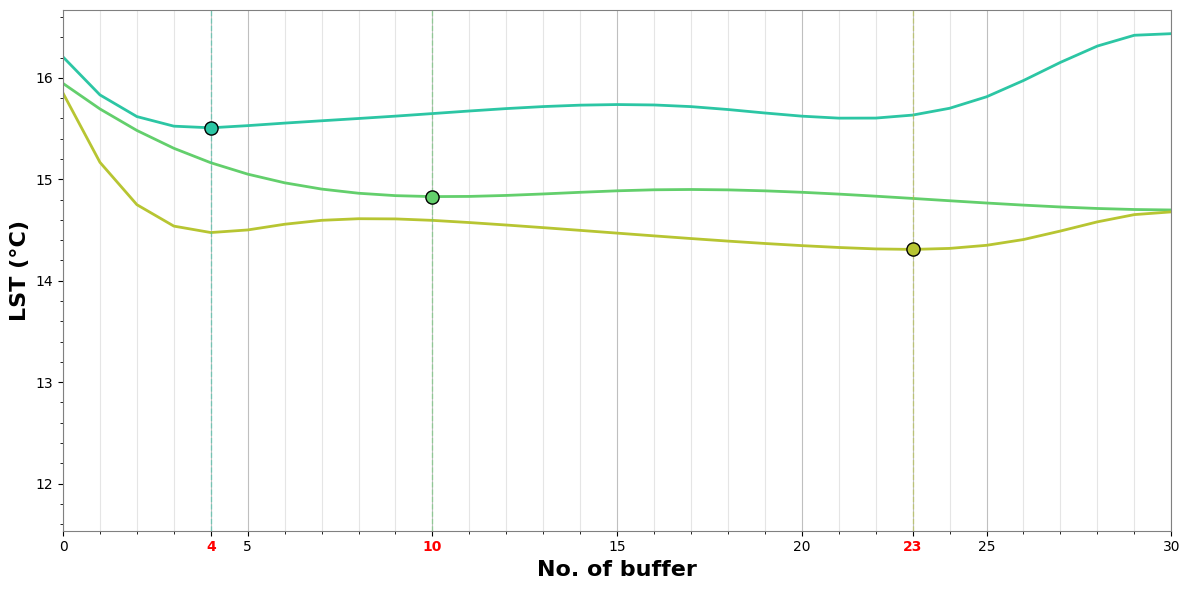

In [155]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_tp = pd.DataFrame(winter_turning_points_near_zero)

# --------------------------
# 0. Create figure FIRST
# --------------------------
plt.figure(figsize=(12, 6))
ax = plt.gca()

# --------------------------
# 1. Plot curves
# --------------------------
for direction, group in winter_df_spline.groupby("direction"):

    group = group.sort_values("buffer_no")

    plt.plot(
        group["buffer_no"],
        group["lst_mean"],
        linewidth=2,
        color=colors.get(direction, "black"),
        label=f"Direction {direction}"
    )

# --------------------------
# 2. Plot near-zero slope points
# --------------------------
for _, row in df_tp.iterrows():

    plt.scatter(
        row["buffer_no"],
        row["lst"],
        s=90,
        color=colors.get(row["direction"], "black"),
        edgecolor="black",
        zorder=5
    )

    # vertical line (optional but useful)
    plt.axvline(
        x=row["buffer_no"],
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        color=colors.get(row["direction"], "black")
    )

# --------------------------
# 3. Labels
# --------------------------
plt.xlabel("No. of buffer", fontsize=16, fontweight="bold")
plt.ylabel("LST (°C)", fontsize=16, fontweight="bold")

# --------------------------
# 4. X-axis ticks
# --------------------------
plt.xticks(np.arange(0, 31, 5))

ax = plt.gca()

# --------------------------
# Base ticks
# --------------------------
base_ticks = list(np.arange(0, 31, 5))

# --------------------------
# Turning points (near-zero slope)
# --------------------------
turn_ticks = df_tp["buffer_no"].astype(int).tolist()

# --------------------------
# Merge + clean
# --------------------------
all_ticks = sorted(set(base_ticks + turn_ticks))

ax.set_xticks(all_ticks)
ax.set_xticklabels([str(t) for t in all_ticks])

# --------------------------
# Highlight turning points
# --------------------------
for label, tick in zip(ax.get_xticklabels(), all_ticks):
    if tick in turn_ticks:
        label.set_fontweight("bold")
        label.set_color("red")  


# --------------------------
# 5. Grid styling
# --------------------------
plt.grid(axis="x", which="major", color="grey", alpha=0.5)
plt.minorticks_on()
plt.grid(axis="x", which="minor", color="grey", alpha=0.2)

ax.set_xlim(0, 30)

# --------------------------
# 6. Clean spines
# --------------------------
for spine in ax.spines.values():
    spine.set_edgecolor("grey")

ax.set_facecolor("white")

# --------------------------
# 7. Legend (bottom)
# --------------------------
#plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=4)

plt.tight_layout()

# Save
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/PhD_chapter2_IGARSS/output/figures/winter_turning_points_near_zero_slope.png", dpi=300, bbox_inches="tight")

plt.show()


# References
Yang, Q., Ye, R., Chakraborty, T. C., Hu, T., & Liu, Y. (2026). Estimation of intensity, footprint, and capacity of surface urban heat islands using a direction-enhanced adaptive synchronous extraction (DEASE) method. Remote Sensing of Environment, 333, 115118. https://doi.org/https://doi.org/10.1016/j.rse.2025.115118 

